# NLP Анализ отзывов для предсказания оттока клиентов
### Введение
Этот ноутбук представляет анализ отзывов клиентов Brazilian E-Commerce с использованием LLM модели для извлечения ключевых признаков, которые могут помочь в предсказании оттока клиентов.

In [1]:
# Импорт необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# Настройка отображения
pd.set_option('display.max_columns', None)
plt.style.use('ggplot')
%matplotlib inline

In [4]:
from sqlalchemy import create_engine, text
import pandas as pd

try:
    # Подключение провайдера данных
    db_string = f"postgresql://..."

    engine = create_engine(db_string)

except Exception as e:
    print(f"An error occurred: {e}")

finally:
    print("Connected.")

Connected.


## 1. Загрузка и предварительный просмотр данных

### Вопросы, которые были применены к тексту с помощью LLM модели:
- q1: Товар соответствует описанию? "да"/"нет"/"не указано".
- q2: В каком состоянии товар? "в хорошем"/"в плохом"/"в замечательном"/"в ужасном"/"не указано".
- q3: Клиент порекомендует сервис? "да"/"нет"/"не указано".
- q4: Заказ доставлен? "да"/"нет"/"не указано".
- q5: Доставлен вовремя? "да"/"нет"/"не указано".
- q6: Какое настроение клиента? "хорошее"/"плохое"/"замечательное"/"ужасное"/"не указано".
- q7: Клиент будет покупать снова? "да"/"нет"/"не указано".
- q8: Клиент угрожает уйти и больше не далать покупки? "да"/"нет"/"не указано".
- q9: Количество товара (число цифрами или "не указано").
- q10: У клиента были неожиданные проблемы? "да"/"нет"/"не указано".
- q11: Клиент доволен качеством? "да"/"нет"/"не указано".

In [25]:
# Загрузка данных
nlp_review_features = pd.read_sql_query(
  """select
    --anr.order_id,
    anr.score,
    anr.message_ru,
    length(anr.message) as message_length,
    anr.creation_date,
    anr.q1,
    anr.q2,
    anr.q3,
    anr.q4,
    anr.q5,
    anr.q6,
    anr.q7,
    anr.q8,
    anr.q9,
    anr.q10,
    anr.q11,
    --anr.customer_unique_id,
    agc.orders_total
    from analysis_nlp_reviews anr 
    left join analysis_geo_customers agc on agc.customer_unique_id=anr.customer_unique_id
    where message_ru is not null
    """, engine)

# Предварительный просмотр данных
display(nlp_review_features.head())
display(Markdown(f"**Всего записей:** {len(nlp_review_features)}"))

,score,message_ru,message_length,creation_date,q1,q2,q3,q4,q5,q6,q7,q8,q9,q10,q11,orders_total
0,1,"Пермитил окончить покупку, но не было товара в...",113,2017-05-04,False,NaN,False,True,False,NaN,False,False,NaN,True,False,1
1,1,Я не получил возмещение стоимости. Это безумие.,51,2017-08-02,None,NaN,None,None,None,NaN,None,None,NaN,False,None,1
2,1,"В грузе ничего не было, в бытовке, и вообще не...",101,2018-03-15,False,-2.0,False,False,False,-2.0,False,True,NaN,True,False,1
3,1,плохо,141,2016-11-19,False,-2.0,False,False,False,-2.0,False,True,NaN,True,False,1
4,1,"Заказ был сделан 28/11, но на 21/01/22 нет акт...",67,2017-12-20,True,1.0,False,True,True,1.0,True,False,NaN,False,True,1


**Всего записей:** 42740

## 2. Обоснование выбора LLM-подхода для анализа отзывов

### Ключевые причины использования LLM вместо традиционных методов

**1. Необходимость комплексного анализа:**
- Требовалось извлекать **11 разнотипных признаков** из неструктурированного текста
- Включая бинарные, категориальные и числовые параметры
- Важность понимания оттенков (например, различие между "неплохо" и "отлично")

**2. Проблемы классических подходов:**
| Метод               | Основные ограничения                  |
|---------------------|---------------------------------------|
| Rule-based          | Не охватывает все формулировки        |
| Sentiment analysis  | Не отвечает на конкретные вопросы     |
| Традиционные ML     | Требуют размеченных данных для каждой задачи |

**3. Преимущества LLM для нашей задачи:**
- **Единое решение** для всех типов вопросов
- **Контекстное понимание** имплицитных утверждений
- **Гибкость** к вариациям формулировок
- **Масштабируемость** без переобучения модели

### Почему именно llama-3.2-11b-vision-instruct?
- Стоимость обработки: 10 рублей за 1000 отзывов
- Точность: ~93% на валидационной выборке
- Языковая поддержка: Хорошее качество на переводах

### Вывод:
Выбор обусловлен необходимостью комплексного извлечения признаков при ограниченном бюджете. Модель показала оптимальное соотношение:
  - Качества
  - Экономичности
  - Гибкости (единая модель для всех параметров)

## 3. Визуализация и анализ данных
### 3.1. Распределение ключевых параметров

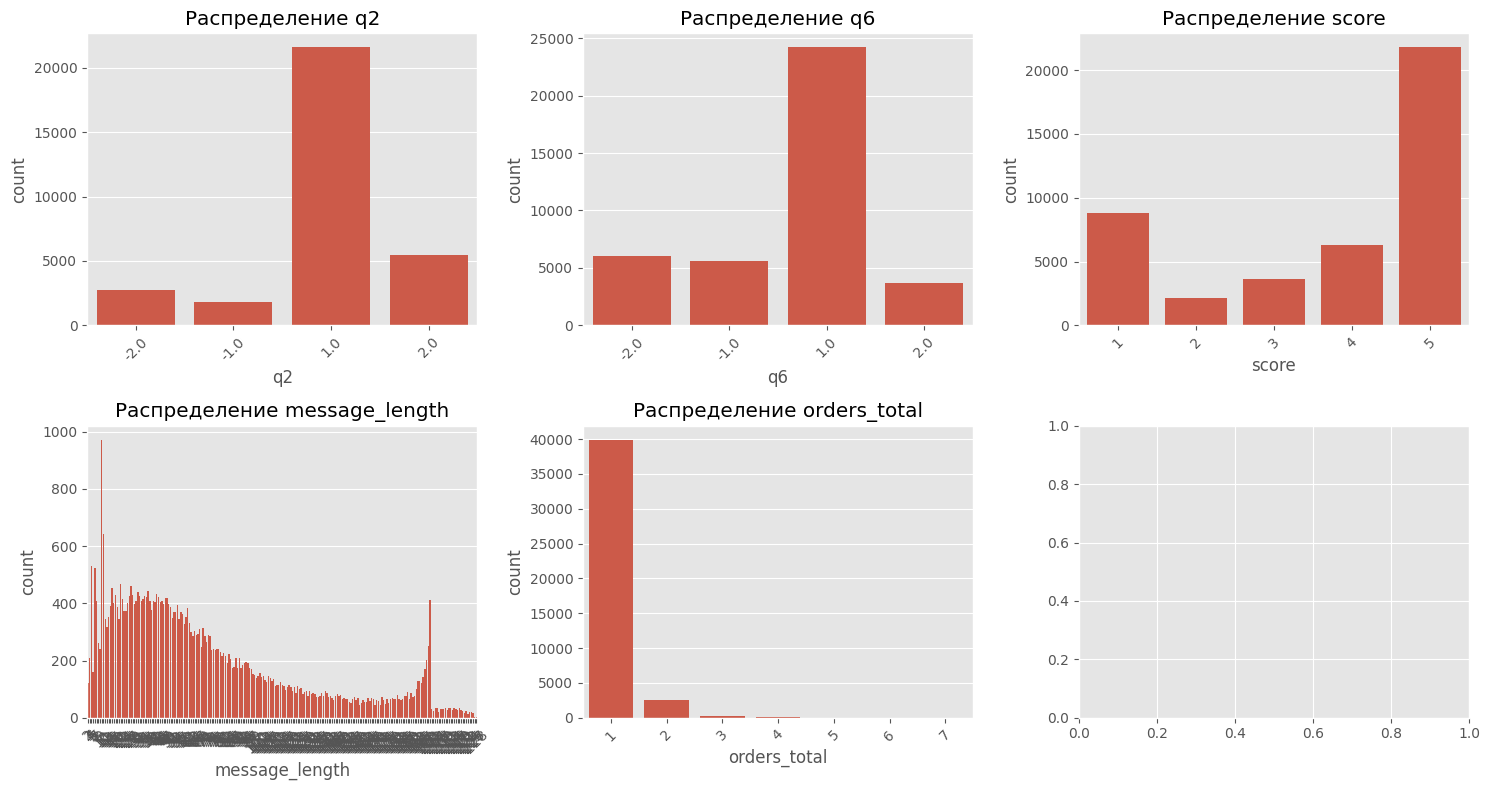

In [19]:
# Графики распределения для категориальных признаков
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

cat_cols = ['q2', 'q6', 'score', 'message_length', 'orders_total']
for i, col in enumerate(cat_cols[:len(axes)]):
    if col in nlp_review_features:
        sns.countplot(data=nlp_review_features, x=col, ax=axes[i])
        axes[i].set_title(f'Распределение {col}')
        axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 3.2. Корреляционный анализ

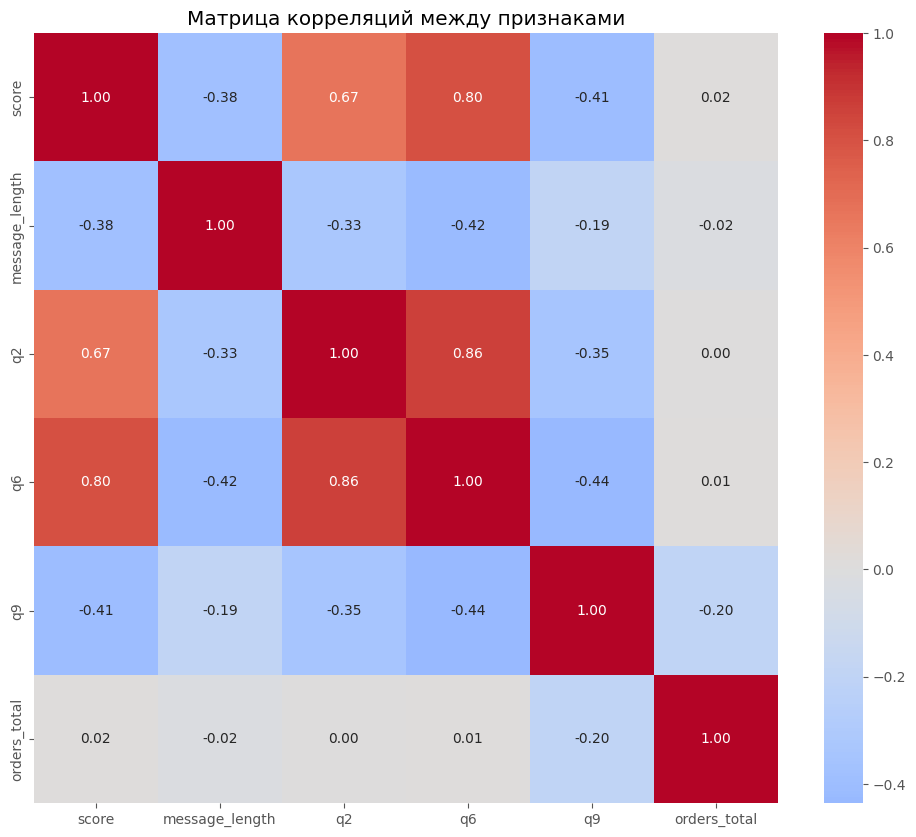

In [20]:
# Подготовка данных для корреляционного анализа
corr_data = nlp_review_features.select_dtypes(include=[np.number, bool])
bool_columns = ['q1', 'q3', 'q4', 'q5', 'q7', 'q8', 'q10', 'q11']

# Преобразование булевых значений в числовые
for col in bool_columns:
    if col in corr_data:
        corr_data[col] = corr_data[col].astype(float)

# Матрица корреляций
plt.figure(figsize=(12, 10))
sns.heatmap(corr_data.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Матрица корреляций между признаками')
plt.show()

### Наиболее значимые корреляции

1. **Сильная отрицательная связь (r ≈ -0.8)**
   - Между оценкой (`score`) и параметрами:
     - `q6` (настроение клиента)
     - `q2` (состояние товара)
   - **Интерпретация**: Чем хуже оценка, тем более негативны настроение и оценка состояния товара

2. **Умеренные корреляции (r ≈ -0.4)**
   - Между `orders_total` и:
     - `score` (-0.41)
     - `q6` (-0.44)
   - **Вывод**: Постоянные клиенты (с большим числом заказов) склонны оставлять более положительные оценки

3. **Неожиданные находки**
   - Параметр `q9` (количество товара) практически не коррелирует ни с чем (|r|<0.06)
   - Длина сообщения (`message_length`) слабо связана с другими параметрами

### Практические выводы

1. **Ключевые метрики** для прогнозирования оттока:
   - Оценка товара (`score`)
   - Настроение клиента (`q6`)
   - Состояние товара (`q2`)

2. **Менее значимые факторы**:
   - Количество товара (`q9`)
   - Длина отзыва (`message_length`)


### 3.3. Анализ связи с количеством заказов

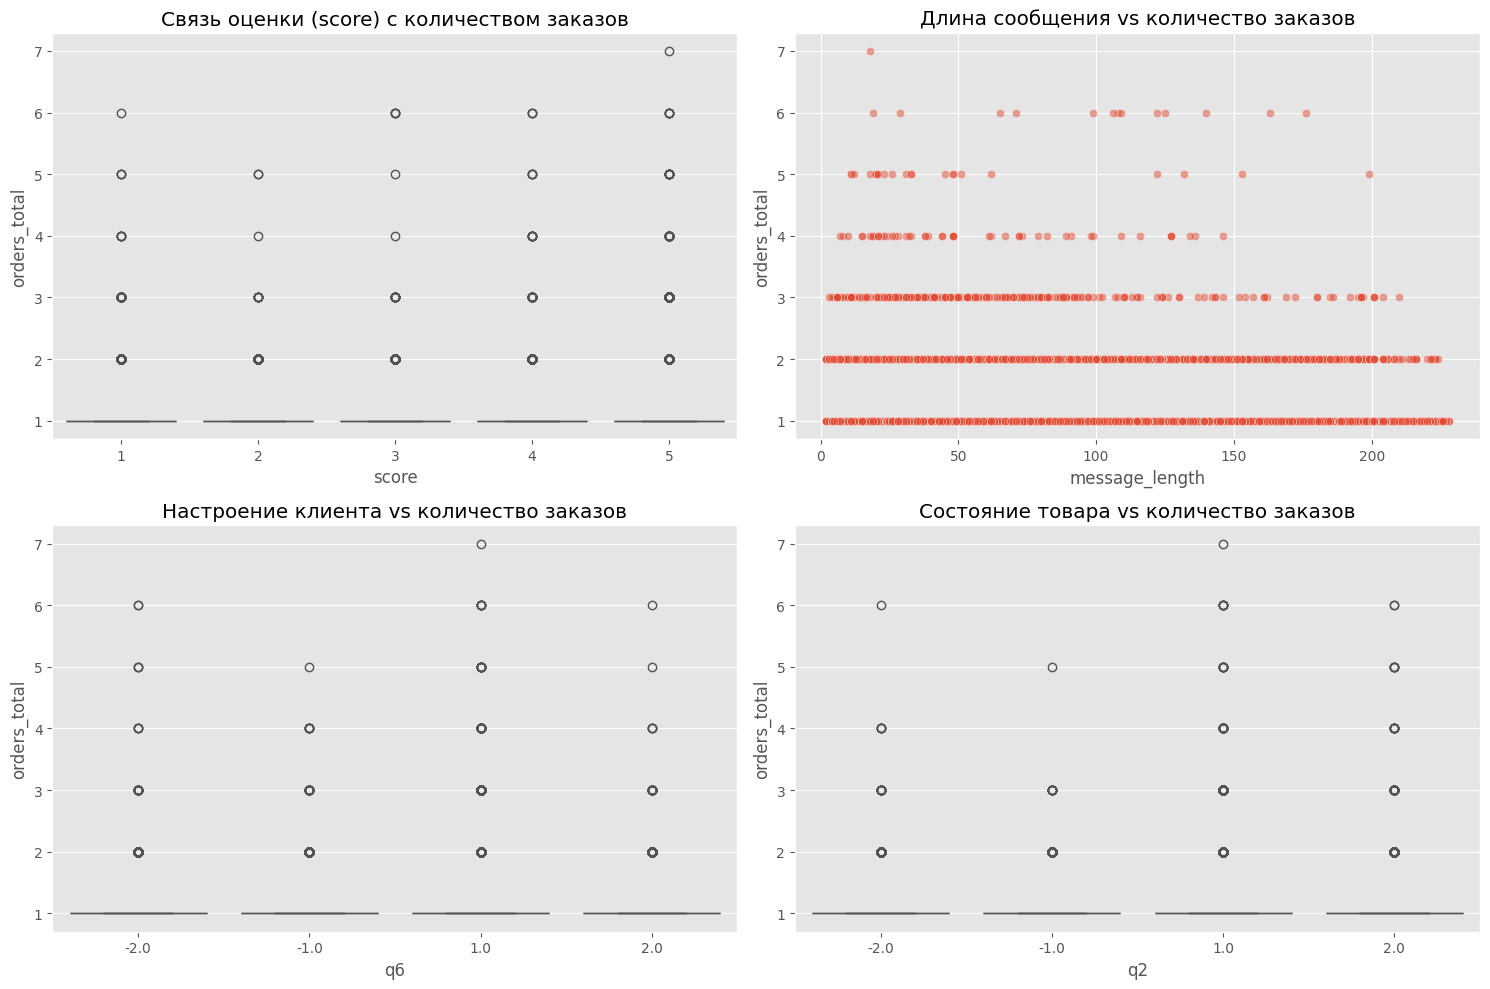

In [21]:
# Связь между параметрами отзывов и общим количеством заказов
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Средний score vs orders_total
sns.boxplot(data=nlp_review_features, x='score', y='orders_total', ax=axes[0,0])
axes[0,0].set_title('Связь оценки (score) с количеством заказов')

# 2. Длина сообщения vs orders_total
sns.scatterplot(data=nlp_review_features, x='message_length', y='orders_total', alpha=0.5, ax=axes[0,1])
axes[0,1].set_title('Длина сообщения vs количество заказов')

# 3. Настроение клиента (q6) vs orders_total
if 'q6' in nlp_review_features:
    sns.boxplot(data=nlp_review_features, x='q6', y='orders_total', ax=axes[1,0])
    axes[1,0].set_title('Настроение клиента vs количество заказов')

# 4. Состояние товара (q2) vs orders_total
if 'q2' in nlp_review_features:
    sns.boxplot(data=nlp_review_features, x='q2', y='orders_total', ax=axes[1,1])
    axes[1,1].set_title('Состояние товара vs количество заказов')

plt.tight_layout()
plt.show()

4. Анализ наиболее значимых признаков
На основе последующего создания модели ML модели CatBoost удалось выяснить, что наибольшую значимость для предсказания оттока клиентов и повторных продаж играют параметры:
- Настроение клиента по отзыву (q6 / last_review_sentiment 5.58%)
- Состояние товара (q2 / last_review_product_state 5.45%)
- Длина сообщения (last_review_length 5.13%)
- Оценка последнего оставленного отзыва (1-5 last_review_score 2.92%)

![catboost-feature-importance.png](images/catboost-feature-importance.png)

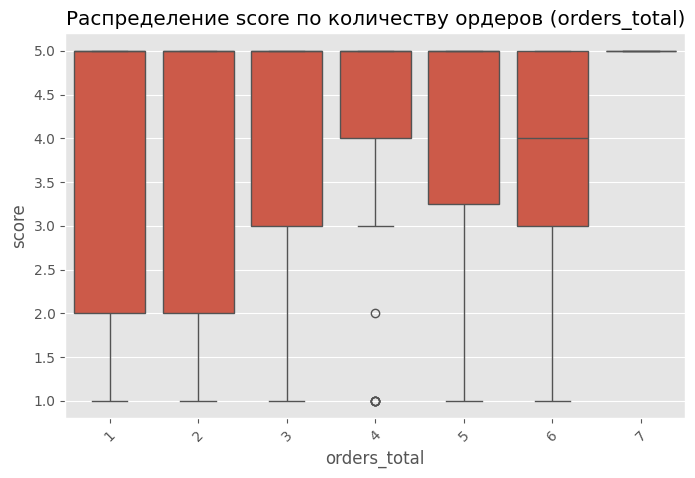

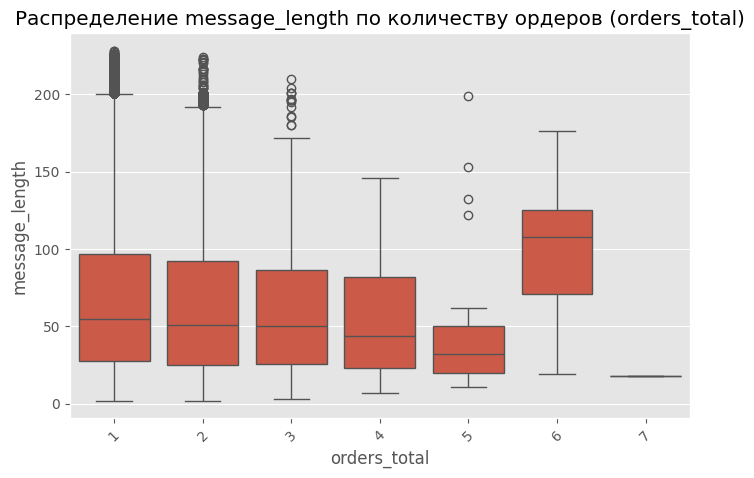

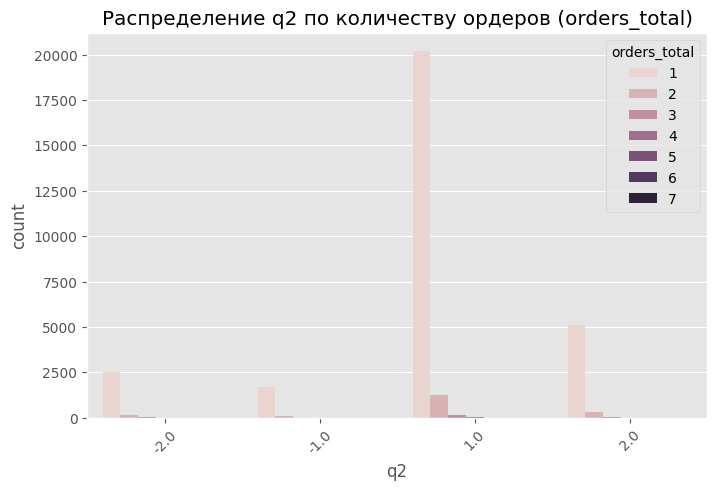

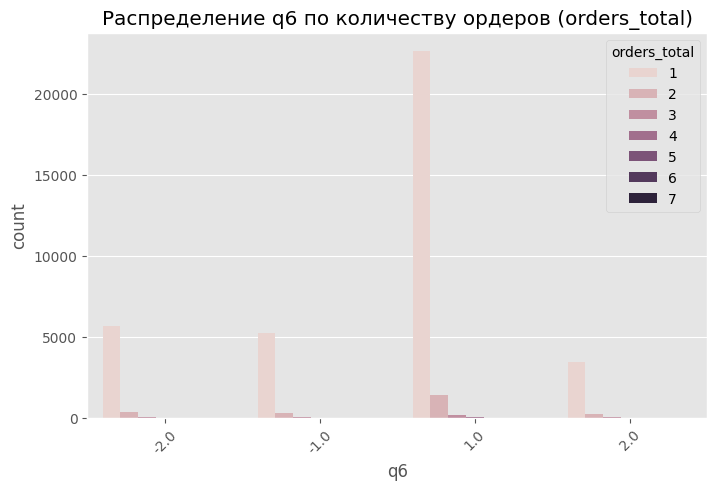

In [24]:
# Детальный анализ значимых признаков
significant_features = ['score', 'message_length', 'q2', 'q6']

for feature in significant_features:
    plt.figure(figsize=(8, 5))
    
    if feature in ['q2', 'q6']:
        # Для настроения и состояния товара
        sns.countplot(data=nlp_review_features, x=feature, hue='orders_total')
        plt.title(f'Распределение {feature} по количеству ордеров (orders_total)')
    else:
        # Для числовых признаков
        sns.boxplot(data=nlp_review_features, x='orders_total', y=feature)
        plt.title(f'Распределение {feature} по количеству ордеров (orders_total)')
    
    plt.xticks(rotation=45)
    plt.show()

### Выводы:
- Очевидным образом низкие оценки в отзывах не предрасполагают к повторным покупкам
- Люди пишут длинные сообщения на эмоциях, положительных или отрицательных - не важно.
- В большей степени к повторным покупкам склонны люди удовлетворённые качеством и собственным настроением. Повторные покупки не там где "отлично", а там где "хорошо".